# MGMT298D: Science and Strategy of AI
### Week 2 - Tree-based Predictions
### Application: Vehicle Pricing

## Import Libraries and Data

In [3]:
# Import necessary libraries for data manipulation, machine learning, and metrics.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

df = pd.read_csv("https://raw.githubusercontent.com/ucla-anderson-SSAI/SSAI/refs/heads/main/range_rover.csv")

## Data Preparation

In [5]:
# Encode categorical variables for tree-based models
categorical_cols = ["trim", "state", "color"]
encoders = {}

for col in categorical_cols:
    encoders[col] = LabelEncoder()
    df[f"{col}_enc"] = encoders[col].fit_transform(df[col])

feature_cols = ["year", "mileage", "trim_enc", "state_enc", "color_enc"]
X = df[feature_cols]
y = df["sellingprice"]

## Model A: Decision Tree

In [7]:
model_A = DecisionTreeRegressor(random_state=42, max_depth=5)
scores_A = cross_val_score(model_A, X, y, cv=10, scoring="neg_mean_absolute_error")
pred_A = cross_val_predict(model_A, X, y, cv=10)
print(f"Model A — Mean absolute error = ${-scores_A.mean():,.2f} (±${scores_A.std():,.2f})")

Model A — Mean absolute error = $3,454.26 (±$699.71)


## Model B: Random Forest

In [9]:
model_B = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=5)
scores_B = cross_val_score(model_B, X, y, cv=10, scoring="neg_mean_absolute_error")
pred_B = cross_val_predict(model_B, X, y, cv=10)
print(f"Model B — Mean absolute error = ${-scores_B.mean():,.2f} (±${scores_B.std():,.2f})")

Model B — Mean absolute error = $3,114.18 (±$828.23)


## Model C: XGBoost

In [11]:
model_C = xgb.XGBRegressor(n_estimators=50, random_state=42, max_depth=5, learning_rate = 0.1)
scores_C = cross_val_score(model_C, X, y, cv=10, scoring="neg_mean_absolute_error")
pred_C = cross_val_predict(model_C, X, y, cv=10)
print(f"Model C — Mean absolute error = ${-scores_C.mean():,.2f} (±${scores_C.std():,.2f})")

Model C — Mean absolute error = $3,033.75 (±$737.15)


## Model Comparison Visualization

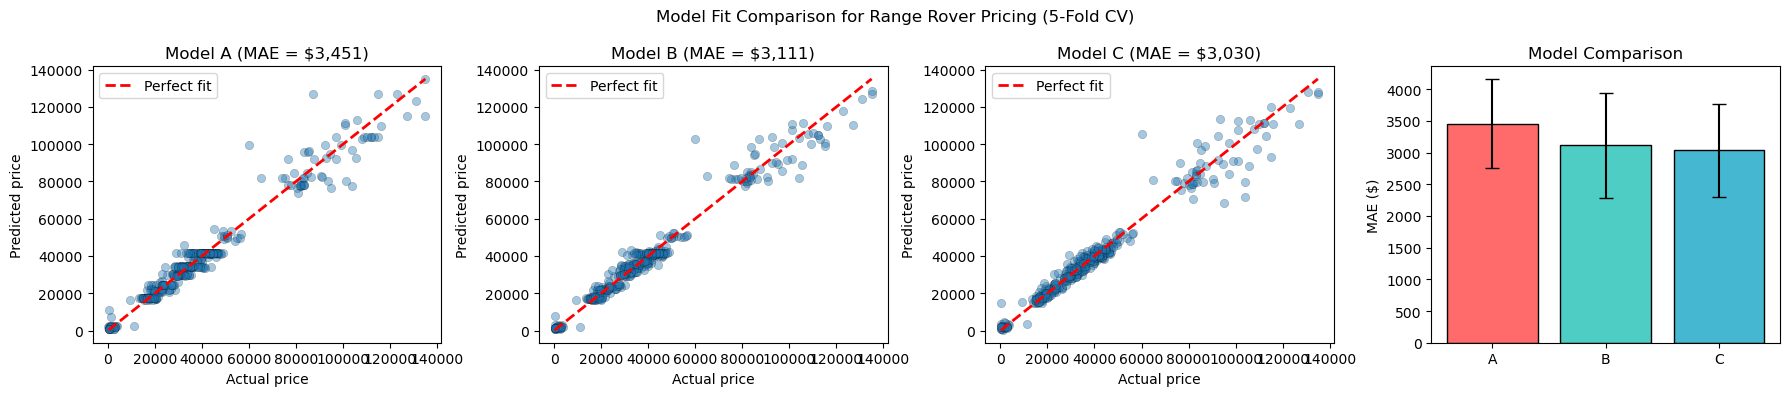

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

models = [("Model A", pred_A), ("Model B", pred_B), ("Model C", pred_C)]

for ax, (name, pred) in zip(axes[:3], models):
    mae = mean_absolute_error(y, pred)
    ax.scatter(y, pred, alpha=0.4, edgecolor="k", linewidth=0.3)
    lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=2, label="Perfect fit")
    ax.set_xlabel("Actual price")
    ax.set_ylabel("Predicted price")
    ax.set_title(f"{name} (MAE = ${mae:,.0f})")
    ax.legend()

# Bar plot
maes = [-scores_A.mean(), -scores_B.mean(), -scores_C.mean()]
stds = [scores_A.std(), scores_B.std(), scores_C.std()]
axes[3].bar(["A", "B", "C"], maes, yerr=stds, color=["#ff6b6b", "#4ecdc4", "#45b7d1"], edgecolor="k", capsize=5)
axes[3].set_ylabel("MAE ($)")
axes[3].set_title("Model Comparison")

fig.suptitle("Model Fit Comparison", fontsize=12)
plt.tight_layout()
plt.show()

## Error vs Number of Trees

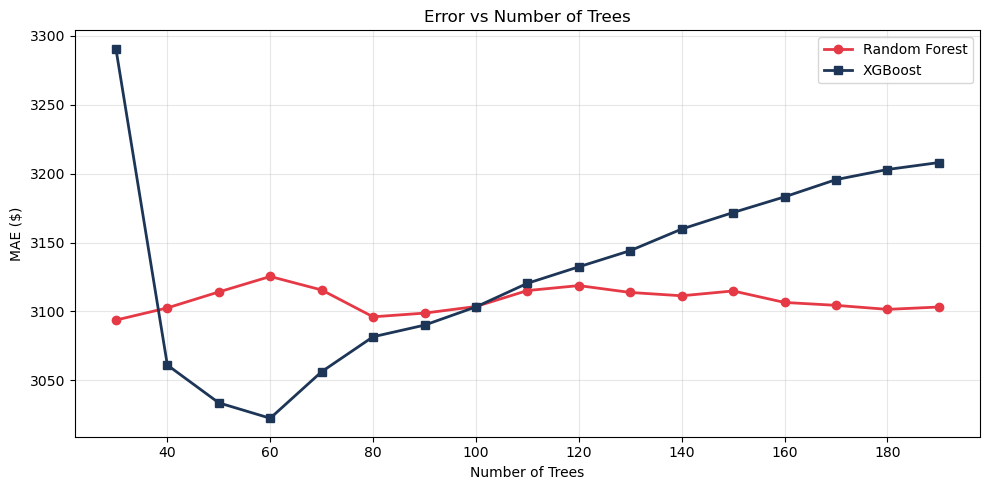

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
n_trees_range = range(30, 200, 10)

# Random Forest
rf_maes = []
for n in n_trees_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=42, max_depth=5)
    scores = cross_val_score(rf, X, y, cv=10, scoring="neg_mean_absolute_error")
    rf_maes.append(-scores.mean())

# XGBoost
xgb_maes = []
for n in n_trees_range:
    xgb_model = xgb.XGBRegressor(n_estimators=n, random_state=42, max_depth=5, learning_rate = 0.1)
    scores = cross_val_score(xgb_model, X, y, cv=10, scoring="neg_mean_absolute_error")
    xgb_maes.append(-scores.mean())

ax.plot(n_trees_range, rf_maes, marker="o", color="#e63946", linewidth=2, markersize=6, label="Random Forest")
ax.plot(n_trees_range, xgb_maes, marker="s", color="#1d3557", linewidth=2, markersize=6, label="XGBoost")
ax.set_xlabel("Number of Trees")
ax.set_ylabel("MAE ($)")
ax.set_title("Error vs Number of Trees")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Feature Importance

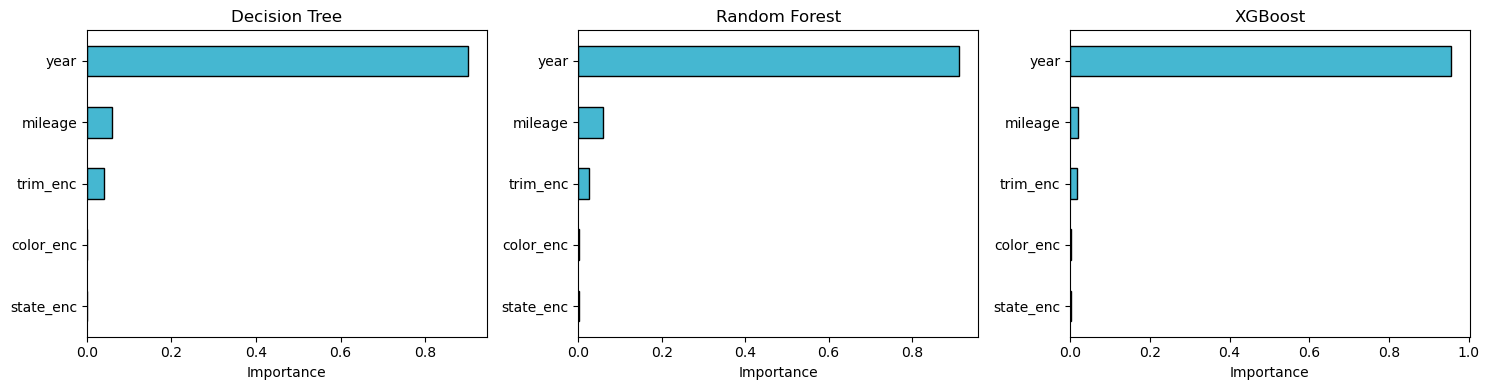

In [17]:
# Fit models on full data for feature importance
model_A.fit(X, y)
model_B.fit(X, y)
model_C.fit(X, y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, [("Decision Tree", model_A), ("Random Forest", model_B), ("XGBoost", model_C)]):
    importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
    importance.plot(kind="barh", ax=ax, color="#45b7d1", edgecolor="k")
    ax.set_xlabel("Importance")
    ax.set_title(name)

plt.tight_layout()
plt.show()